# Punto 5 — Preparación de datos para Machine Learning

**Continuación del caso base normalizado.**  
Objetivo: definir variable respuesta (VIOLENCIA_FISICA), variables predictoras, dividir en conjunto de entrenamiento y prueba con estratificación, y analizar el balance de clases para el informe.

In [45]:
%pip install pandas numpy matplotlib seaborn scipy scikit-learn pyreadstat catboost -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [46]:
import pandas as pd
from pathlib import Path
import pyreadstat
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.exceptions import ConvergenceWarning
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt
import warnings

## 1. Carga y preparación de datos (violencia intrafamiliar)

Se replica la misma carga y mapeo de departamentos que en el notebook **caso_base_normalizado**: archivos `.sav` de violencia, columna `ANIO` y columna `Departamento` desde `DEPTO_MCPIO`.

In [47]:
DEPARTAMENTOS_MAP = {
    1: 'Guatemala', 2: 'El Progreso', 3: 'Sacatepéquez', 4: 'Chimaltenango',
    5: 'Escuintla', 6: 'Santa Rosa', 7: 'Sololá', 8: 'Totonicapán',
    9: 'Quetzaltenango', 10: 'Suchitepéquez', 11: 'Retalhuleu', 12: 'San Marcos',
    13: 'Huehuetenango', 14: 'Quiché', 15: 'Baja Verapaz', 16: 'Alta Verapaz',
    17: 'Petén', 18: 'Izabal', 19: 'Zacapa', 20: 'Chiquimula',
    21: 'Jalapa', 22: 'Jutiapa'
}


def cargar_violencia(ruta_carpeta='data/violencia-intrafamiliar'):
    archivos = sorted(Path(ruta_carpeta).glob('*.sav'))
    listas = []
    for archivo in archivos:
        df_t, _ = pyreadstat.read_sav(str(archivo))
        anio = int(archivo.stem.split('-')[0])
        df_t['ANIO'] = anio
        listas.append(df_t)
    df = pd.concat(listas, ignore_index=True)
    codigo_depto = df['DEPTO_MCPIO'].dropna().astype(int).floordiv(100)
    df['Departamento'] = codigo_depto.map(DEPARTAMENTOS_MAP).reindex(df.index)
    return df


df_violencia = cargar_violencia()
print(f"Registros cargados: {len(df_violencia):,}")
print(f"Periodo: {df_violencia['ANIO'].min()}-{df_violencia['ANIO'].max()}")
print(f"Departamento mapeado: {df_violencia['Departamento'].notna().sum():,} ({df_violencia['Departamento'].notna().mean()*100:.1f}%)")

Registros cargados: 387,257
Periodo: 2009-2020
Departamento mapeado: 387,257 (100.0%)


## 2. Variable respuesta: VIOLENCIA_FISICA

Se deriva de **HEC_TIPAGRE** (tipo de agresión): los códigos cuyo primer dígito es 1 incluyen agresión física (1222, 1122, 1212, 1111, etc.). Codificación numérica estándar para clasificación: **1** = violencia física, **0** = no violencia física. Se excluyen filas con valor faltante o no válido en HEC_TIPAGRE.

In [48]:
def construir_target_violencia_fisica(dataframe):
    tipagre = pd.to_numeric(dataframe['HEC_TIPAGRE'], errors='coerce')
    mascara_valida = tipagre.notna() & (tipagre >= 1000) & (tipagre < 10000)
    serie = pd.Series(index=dataframe.index, dtype=object)
    serie.loc[mascara_valida] = (
        (tipagre.loc[mascara_valida].astype(int) // 1000) == 1
    ).map({True: 1, False: 0})
    return serie


df_violencia['VIOLENCIA_FISICA'] = construir_target_violencia_fisica(df_violencia)
filas_validas = df_violencia['VIOLENCIA_FISICA'].notna()
df_ml = df_violencia.loc[filas_validas].copy()
print("Variable respuesta VIOLENCIA_FISICA (1 = violencia física, 0 = no):")
print(df_ml['VIOLENCIA_FISICA'].value_counts().sort_index())
print(f"\nRegistros con target válido: {len(df_ml):,}")

Variable respuesta VIOLENCIA_FISICA (1 = violencia física, 0 = no):
VIOLENCIA_FISICA
0    154306
1    232951
Name: count, dtype: int64

Registros con target válido: 387,257


## 3. Variables predictoras (features) y matriz de trabajo

Se seleccionan columnas sociodemográficas, geográficas y temporales. Se eliminan filas con NaN en alguna feature o en el target para obtener el dataset final para el split.

In [49]:
COLUMNAS_FEATURES = [
    'VIC_SEXO', 'VIC_EDAD', 'VIC_ALFAB', 'VIC_ESCOLARIDAD',
    'VIC_EST_CIV', 'VIC_GRUPET', 'Departamento', 'ANIO'
]


def construir_matriz_features(dataframe, columnas):
    disponibles = [c for c in columnas if c in dataframe.columns]
    return dataframe[disponibles].copy()


features = construir_matriz_features(df_ml, COLUMNAS_FEATURES)
target = df_ml['VIOLENCIA_FISICA']
columnas_usadas = list(features.columns)
print("Columnas usadas como features:", columnas_usadas)

filas_completas = features.notna().all(axis=1) & target.notna()
features_limpio = features.loc[filas_completas].copy()
target_limpio = target.loc[filas_completas].copy()

print(f"\nRegistros tras eliminar NaN: {len(features_limpio):,}")
print(f"  Entregados a train/test: X = {len(features_limpio):,} filas, {len(columnas_usadas)} columnas")

Columnas usadas como features: ['VIC_SEXO', 'VIC_EDAD', 'VIC_ALFAB', 'VIC_ESCOLARIDAD', 'VIC_EST_CIV', 'VIC_GRUPET', 'Departamento', 'ANIO']

Registros tras eliminar NaN: 385,519
  Entregados a train/test: X = 385,519 filas, 8 columnas


## 4. División entrenamiento / prueba (80 % / 20 %)

Se usa **estratificación** por la variable respuesta para mantener la proporción de clases (1/0) en train y test. Semilla fija para reproducibilidad.

In [50]:
PROPORCION_PRUEBA = 0.2
SEMILLA = 42

features_entrenamiento, features_prueba, target_entrenamiento, target_prueba = train_test_split(
    features_limpio,
    target_limpio,
    test_size=PROPORCION_PRUEBA,
    stratify=target_limpio,
    random_state=SEMILLA
)

total = len(features_limpio)
n_train = len(features_entrenamiento)
n_test = len(features_prueba)
print("División entrenamiento / prueba (estratificada)")
print("=" * 60)
print(f"  Entrenamiento: {n_train:,} registros ({n_train/total*100:.1f} %)")
print(f"  Prueba:       {n_test:,} registros ({n_test/total*100:.1f} %)")
print(f"  Total:        {total:,} registros")

División entrenamiento / prueba (estratificada)
  Entrenamiento: 308,415 registros (80.0 %)
  Prueba:       77,104 registros (20.0 %)
  Total:        385,519 registros


## 5. Análisis de balance de la variable respuesta

Proporción de cada clase (1 = violencia física, 0 = no) en el dataset global, en entrenamiento y en prueba. La estratificación mantiene proporciones similares en ambos conjuntos.

In [51]:
ETIQUETAS_CLASE = {1: "1 (violencia física)", 0: "0 (no violencia física)"}


def reportar_balance(target_global, target_train, target_test):
    def resumen(serie, etiqueta):
        conteo = serie.value_counts().sort_index()
        total = len(serie)
        print(f"\n  {etiqueta} (n = {total:,})")
        for clase in conteo.index:
            etiq = ETIQUETAS_CLASE.get(clase, clase)
            pct = conteo[clase] / total * 100
            print(f"    {etiq}: {conteo[clase]:,} ({pct:.1f} %)")

    print("Balance de la variable VIOLENCIA_FISICA (1 = violencia física, 0 = no)")
    print("=" * 60)
    resumen(target_global, "Dataset completo (antes del split)")
    resumen(target_train, "Entrenamiento")
    resumen(target_test, "Prueba")

    pct_clase_1 = (target_global == 1).mean() * 100
    if 40 <= pct_clase_1 <= 60:
        balance = "balanceado (proporciones cercanas a 50/50)"
    else:
        balance = "desbalanceado (una clase domina)"
    print(f"\nConclusión: el dataset está {balance}.")


reportar_balance(target_limpio, target_entrenamiento, target_prueba)

Balance de la variable VIOLENCIA_FISICA (1 = violencia física, 0 = no)

  Dataset completo (antes del split) (n = 385,519)
    0 (no violencia física): 153,789 (39.9 %)
    1 (violencia física): 231,730 (60.1 %)

  Entrenamiento (n = 308,415)
    0 (no violencia física): 123,031 (39.9 %)
    1 (violencia física): 185,384 (60.1 %)

  Prueba (n = 77,104)
    0 (no violencia física): 30,758 (39.9 %)
    1 (violencia física): 46,346 (60.1 %)

Conclusión: el dataset está desbalanceado (una clase domina).


In [52]:
tabla_balance = pd.DataFrame({
    'Conjunto': ['Completo', 'Entrenamiento', 'Prueba'],
    'N': [len(target_limpio), len(target_entrenamiento), len(target_prueba)],
    'Clase 1 (n)': [
        (target_limpio == 1).sum(),
        (target_entrenamiento == 1).sum(),
        (target_prueba == 1).sum()
    ],
    'Clase 0 (n)': [
        (target_limpio == 0).sum(),
        (target_entrenamiento == 0).sum(),
        (target_prueba == 0).sum()
    ]
})
tabla_balance['% clase 1'] = (tabla_balance['Clase 1 (n)'] / tabla_balance['N'] * 100).round(1)
tabla_balance['% clase 0'] = (tabla_balance['Clase 0 (n)'] / tabla_balance['N'] * 100).round(1)
print("Resumen para el informe (1 = violencia física, 0 = no):")
display(tabla_balance)

Resumen para el informe (1 = violencia física, 0 = no):


,Conjunto,N,Clase 1 (n),Clase 0 (n),% clase 1,% clase 0
0,Completo,385519,231730,153789,60.1,39.9
1,Entrenamiento,308415,185384,123031,60.1,39.9
2,Prueba,77104,46346,30758,60.1,39.9


### Resumen para el informe (Punto 5)

Se realizó una división aleatoria estratificada del dataset utilizando la variable respuesta VIOLENCIA_FISICA, con el objetivo de mantener la proporción de las clases en los conjuntos de entrenamiento y prueba.

El dataset final utilizado para el modelado contiene 385,519 registros, luego de eliminar filas con valores faltantes en las variables seleccionadas.

La división se realizó utilizando una proporción de:

80 % de los datos para entrenamiento

20 % de los datos para prueba

Para garantizar la reproducibilidad del experimento se utilizó una semilla fija (random_state = 42).

La estratificación permitió mantener proporciones similares de las clases “Sí” y “No” en ambos conjuntos.

En el dataset completo la distribución de clases es aproximadamente:

Sí (violencia física): 60.1 %

No (sin violencia física): 39.9 %

Debido a que ninguna de las clases supera una proporción extremadamente dominante, el dataset presenta un leve desbalance, pero no lo suficientemente alto como para requerir técnicas adicionales de balanceo en esta etapa del análisis.

### Guardado del split (reproducibilidad)

Se guardan los conjuntos crudos de entrenamiento y prueba en `data/split/` para que el Punto 6 pueda cargarlos sin depender de ejecutar Punto 5 en el mismo kernel.

In [53]:
DIRECTORIO_SPLIT = 'data/split'


def guardar_split_entrenamiento_prueba(features_train, features_test, target_train, target_test, directorio=DIRECTORIO_SPLIT):
    Path(directorio).mkdir(parents=True, exist_ok=True)
    features_train.to_csv(Path(directorio) / 'features_entrenamiento.csv', index=False)
    features_test.to_csv(Path(directorio) / 'features_prueba.csv', index=False)
    pd.DataFrame({'VIOLENCIA_FISICA': target_train}).to_csv(
        Path(directorio) / 'target_entrenamiento.csv', index=False
    )
    pd.DataFrame({'VIOLENCIA_FISICA': target_test}).to_csv(
        Path(directorio) / 'target_prueba.csv', index=False
    )
    print(f"Split guardado en {directorio}/:")
    print("  features_entrenamiento.csv, features_prueba.csv,")
    print("  target_entrenamiento.csv, target_prueba.csv")


guardar_split_entrenamiento_prueba(
    features_entrenamiento, features_prueba,
    target_entrenamiento, target_prueba
)

Split guardado en data/split/:
  features_entrenamiento.csv, features_prueba.csv,
  target_entrenamiento.csv, target_prueba.csv


## Carga del split (salida del Punto 5)

Se cargan los conjuntos de entrenamiento y prueba desde `data/split/`. Así Punto 6 puede ejecutarse de forma independiente tras haber ejecutado Punto 5 al menos una vez.

In [54]:
DIRECTORIO_SPLIT = 'data/split'
ruta_split = Path(DIRECTORIO_SPLIT)

features_entrenamiento = pd.read_csv(ruta_split / 'features_entrenamiento.csv')
features_prueba = pd.read_csv(ruta_split / 'features_prueba.csv')
target_entrenamiento = pd.read_csv(ruta_split / 'target_entrenamiento.csv')['VIOLENCIA_FISICA']
target_prueba = pd.read_csv(ruta_split / 'target_prueba.csv')['VIOLENCIA_FISICA']

print(f"Split cargado desde {DIRECTORIO_SPLIT}/")
print(f"  features_entrenamiento: {features_entrenamiento.shape}")
print(f"  features_prueba: {features_prueba.shape}")
print(f"  target_entrenamiento: {len(target_entrenamiento):,}")
print(f"  target_prueba: {len(target_prueba):,}")

Split cargado desde data/split/
  features_entrenamiento: (308415, 8)
  features_prueba: (77104, 8)
  target_entrenamiento: 308,415
  target_prueba: 77,104


---
# Punto 6 — Preprocesamiento para modelos y guardado en CSV

Preparación final de los datos para **Logistic Regression**, **Random Forest** y **CatBoost**: encoding de variables categóricas (one-hot), construcción de las matrices **X_train**, **X_test**, **y_train**, **y_test** y guardado en CSV en `data/ml/` para reproducibilidad.

## 6.1 Columnas categóricas y numéricas

Se definen las listas de columnas para el preprocesador. Categóricas se codifican con one-hot; numéricas se dejan en passthrough para que un solo pipeline sirva a los tres modelos.

In [55]:
COLUMNAS_CATEGORICAS = [
    'VIC_SEXO', 'VIC_ALFAB', 'VIC_ESCOLARIDAD',
    'VIC_EST_CIV', 'VIC_GRUPET', 'Departamento'
]
COLUMNAS_NUMERICAS = ['VIC_EDAD', 'ANIO']


def filtrar_columnas_existentes(dataframe, columnas):
    return [col for col in columnas if col in dataframe.columns]


cat_disponibles = filtrar_columnas_existentes(features_entrenamiento, COLUMNAS_CATEGORICAS)
num_disponibles = filtrar_columnas_existentes(features_entrenamiento, COLUMNAS_NUMERICAS)
print("Categóricas (one-hot):", cat_disponibles)
print("Numéricas (passthrough):", num_disponibles)

Categóricas (one-hot): ['VIC_SEXO', 'VIC_ALFAB', 'VIC_ESCOLARIDAD', 'VIC_EST_CIV', 'VIC_GRUPET', 'Departamento']
Numéricas (passthrough): ['VIC_EDAD', 'ANIO']


## 6.2 Preprocesador y matrices X_train, X_test

Se crea un `ColumnTransformer` que aplica one-hot a las categóricas (con `handle_unknown='ignore'` para test) y passthrough a las numéricas. Se ajusta solo con los datos de entrenamiento y se transforman train y test.

In [56]:
def crear_preprocesador(columnas_categoricas, columnas_numericas):
    transformadores = []
    if columnas_categoricas:
        transformadores.append(
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
             columnas_categoricas)
        )
    if columnas_numericas:
        transformadores.append(('num', 'passthrough', columnas_numericas))
    return ColumnTransformer(transformadores, remainder='drop')


preprocesador = crear_preprocesador(cat_disponibles, num_disponibles)
preprocesador.fit(features_entrenamiento)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehot', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g

In [57]:
def aplicar_preprocesamiento(preprocessor, features_train, features_test):
    matriz_train = preprocessor.transform(features_train)
    matriz_test = preprocessor.transform(features_test)
    nombres = preprocessor.get_feature_names_out()
    return matriz_train, matriz_test, nombres


matriz_entrenamiento, matriz_prueba, nombres_columnas = aplicar_preprocesamiento(
    preprocesador, features_entrenamiento, features_prueba
)

X_train = pd.DataFrame(matriz_entrenamiento, columns=nombres_columnas)
X_test = pd.DataFrame(matriz_prueba, columns=nombres_columnas)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Columnas (primeras 5):", list(X_train.columns[:5]))

X_train: (308415, 67)
X_test: (77104, 67)
Columnas (primeras 5): ['onehot__VIC_SEXO_1.0', 'onehot__VIC_SEXO_2.0', 'onehot__VIC_ALFAB_1.0', 'onehot__VIC_ALFAB_2.0', 'onehot__VIC_ALFAB_9.0']


## 6.3 Variables objetivo y_train, y_test

Se asignan a partir de los targets del Punto 5, como DataFrames con una columna para el guardado en CSV.

In [58]:
NOMBRE_COLUMNA_TARGET = 'VIOLENCIA_FISICA'

y_train = pd.DataFrame({NOMBRE_COLUMNA_TARGET: target_entrenamiento.values})
y_test = pd.DataFrame({NOMBRE_COLUMNA_TARGET: target_prueba.values})
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

y_train: (308415, 1)
y_test: (77104, 1)


## 6.4 Guardado en CSV

Se guardan los cuatro conjuntos en `data/ml/` para reproducibilidad. El directorio se crea si no existe.

In [59]:
def guardar_datasets_csv(X_train_df, X_test_df, y_train_df, y_test_df, directorio='data/ml'):
    Path(directorio).mkdir(parents=True, exist_ok=True)
    X_train_df.to_csv(Path(directorio) / 'X_train.csv', index=False)
    X_test_df.to_csv(Path(directorio) / 'X_test.csv', index=False)
    y_train_df.to_csv(Path(directorio) / 'y_train.csv', index=False)
    y_test_df.to_csv(Path(directorio) / 'y_test.csv', index=False)
    print(f"Archivos guardados en {directorio}/:")
    print("  X_train.csv, X_test.csv, y_train.csv, y_test.csv")


guardar_datasets_csv(X_train, X_test, y_train, y_test)

Archivos guardados en data/ml/:
  X_train.csv, X_test.csv, y_train.csv, y_test.csv


## 6.5 Verificación

Formas de las matrices finales. Listas para entrenar Logistic Regression, Random Forest y CatBoost.

In [60]:
print("Matrices finales para modelado")
print("=" * 50)
print(f"  X_train: {X_train.shape[0]:,} filas, {X_train.shape[1]} columnas")
print(f"  X_test:  {X_test.shape[0]:,} filas, {X_test.shape[1]} columnas")
print(f"  y_train: {y_train.shape[0]:,} filas")
print(f"  y_test:  {y_test.shape[0]:,} filas")
print("\nListo para: Logistic Regression, Random Forest, CatBoost.")

Matrices finales para modelado
  X_train: 308,415 filas, 67 columnas
  X_test:  77,104 filas, 67 columnas
  y_train: 308,415 filas
  y_test:  77,104 filas

Listo para: Logistic Regression, Random Forest, CatBoost.


## 6.6 Aplicación de los algoritmos 

Se aplican los tres algoritmos seleccionados (Logistic Regression, Random Forest, CatBoost) a los datos preprocesados: un modelo por algoritmo con parámetros por defecto, entrenado con `X_train`/`y_train`, predicción sobre `X_test` y reporte de precisión en test. La creación de varios modelos por algoritmo y la búsqueda de hiperparámetros corresponden al Punto 7.

Punto 6 — Precisión en conjunto de prueba



,Algoritmo,Precisión (test)
0,Logistic Regression,63.74%
1,Random Forest,59.80%
2,CatBoost,65.10%


C:\Users\ferna\AppData\Local\Temp\ipykernel_2132\1767599148.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tabla["Algoritmo"], rotation=15, ha="right")


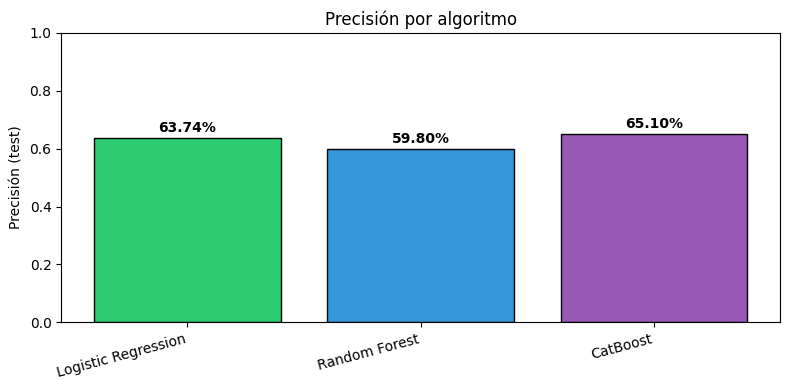

In [61]:
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

y_train_1d = y_train[NOMBRE_COLUMNA_TARGET].values
y_test_1d = y_test[NOMBRE_COLUMNA_TARGET].values

scaler = StandardScaler()
X_train_esc = scaler.fit_transform(X_train)
X_test_esc = scaler.transform(X_test)

resultados = []
modelos = [
    ("Logistic Regression", LogisticRegression(max_iter=2000, random_state=SEMILLA), True),
    ("Random Forest", RandomForestClassifier(random_state=SEMILLA), False),
    ("CatBoost", CatBoostClassifier(verbose=0, random_state=SEMILLA), False),
]
for nombre, modelo, usar_escalado in modelos:
    X_tr = X_train_esc if usar_escalado else X_train
    X_te = X_test_esc if usar_escalado else X_test
    modelo.fit(X_tr, y_train_1d)
    y_pred = modelo.predict(X_te)
    acc = accuracy_score(y_test_1d, y_pred)
    resultados.append({"Algoritmo": nombre, "Precisión (test)": f"{acc:.2%}", "Precisión": acc})

tabla = pd.DataFrame(resultados)
print("Punto 6 — Precisión en conjunto de prueba")
print()
display(tabla[["Algoritmo", "Precisión (test)"]])

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(tabla["Algoritmo"], tabla["Precisión"], color=["#2ecc71", "#3498db", "#9b59b6"], edgecolor="black")
ax.set_ylabel("Precisión (test)")
ax.set_title("Precisión por algoritmo")
ax.set_ylim(0, 1)
ax.set_xticklabels(tabla["Algoritmo"], rotation=15, ha="right")
for i, v in enumerate(tabla["Precisión"]):
    ax.text(i, v + 0.02, f"{v:.2%}", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

---
# Punto 7 — Búsqueda de hiperparámetros y selección del modelo final

Estrategia:

1. **Validación cruzada estratificada (StratifiedKFold, k=5)** sobre el conjunto de entrenamiento para comparar variantes sin "contaminar" el conjunto de prueba.
2. Para cada variante se reportan `train_score` vs `val_score` (CV): una brecha grande indica sobreajuste.
3. Se incluyen técnicas de **regularización L1 (Lasso) y L2 (Ridge)** en Regresión Logística y el parámetro `l2_leaf_reg` en CatBoost.
4. El conjunto de prueba (`X_test`) solo se usa **una vez**, al final, para evaluar el modelo final de cada algoritmo.

## 7.0 Carga de datos y configuración de validación cruzada

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, time
from pathlib import Path

from sklearn.exceptions import ConvergenceWarning
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (StratifiedKFold, cross_validate,
                                     learning_curve)
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report)
from catboost import CatBoostClassifier, Pool

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Cargar datos preprocesados (Punto 6)
X_train = pd.read_csv('data/ml/X_train.csv')
X_test  = pd.read_csv('data/ml/X_test.csv')
y_train = pd.read_csv('data/ml/y_train.csv')['VIOLENCIA_FISICA'].values
y_test  = pd.read_csv('data/ml/y_test.csv')['VIOLENCIA_FISICA'].values

SEMILLA = 42

# ── Submuestra estratificada para CV (50 000 filas) ───────────────────────────
# La validación cruzada sobre 308 K filas × 5 folds sería muy lenta para RF.
# Se usa una submuestra reproducible y estratificada; el modelo final se
# entrena con TODO el conjunto de entrenamiento.
from sklearn.model_selection import train_test_split
X_cv, _, y_cv, _ = train_test_split(
    X_train, y_train,
    train_size=50_000,
    stratify=y_train,
    random_state=SEMILLA
)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
SCORING = 'f1_weighted'

print(f"X_train completo : {X_train.shape}")
print(f"X_cv (submuestra): {X_cv.shape}")
print(f"X_test           : {X_test.shape}")


X_train completo : (308415, 67)
X_cv (submuestra): (50000, 67)
X_test           : (77104, 67)


## 7.1 Regresión Logística — regularización L1 (Lasso) y L2 (Ridge)

Se comparan cuatro configuraciones que cubren el eje regularización↔complejidad:

| # | Penalización | C | Descripción |
|---|---|---|---|
| LR-1 | L2 (Ridge) | 0.01 | Alta regularización → coeficientes muy penalizados |
| LR-2 | L2 (Ridge) | 1.0  | Regularización moderada (valor por defecto) |
| LR-3 | L2 (Ridge) | 100  | Baja regularización → menor penalización |
| LR-4 | L1 (Lasso) | 1.0  | Produce coeficientes dispersos (feature selection implícito) |

`C` es el inverso de la fuerza de regularización: **C pequeño → más regularización**.

In [63]:
scaler_lr = StandardScaler()
X_cv_esc    = scaler_lr.fit_transform(X_cv)
X_train_esc = scaler_lr.transform(X_train)
X_test_esc  = scaler_lr.transform(X_test)

configs_lr = [
    {"penalty": "l2", "C": 0.01,  "solver": "saga", "max_iter": 3000, "random_state": SEMILLA},
    {"penalty": "l2", "C": 1.0,   "solver": "saga", "max_iter": 3000, "random_state": SEMILLA},
    {"penalty": "l2", "C": 100.0, "solver": "saga", "max_iter": 3000, "random_state": SEMILLA},
    {"penalty": "l1", "C": 1.0,   "solver": "saga", "max_iter": 3000, "random_state": SEMILLA},
]

filas_lr = []
for cfg in configs_lr:
    m = LogisticRegression(**cfg)
    cv_res = cross_validate(m, X_cv_esc, y_cv, cv=CV, scoring=SCORING,
                            return_train_score=True, n_jobs=-1)
    filas_lr.append({
        "Modelo":        f"L{cfg['penalty'][-1].upper()}  C={cfg['C']}",
        "Train F1 (CV)": round(cv_res['train_score'].mean(), 4),
        "Val F1 (CV)":   round(cv_res['test_score'].mean(), 4),
        "Desv. val":     round(cv_res['test_score'].std(), 4),
        "Gap (over)":    round(cv_res['train_score'].mean() -
                               cv_res['test_score'].mean(), 4),
    })

df_lr = pd.DataFrame(filas_lr)
print("Regresión Logística — validación cruzada (F1 ponderado, k=5, submuestra 50 k)")
display(df_lr)

mejor_lr_i = df_lr['Val F1 (CV)'].idxmax()
print(f"\nMejor configuración LR: {df_lr.loc[mejor_lr_i,'Modelo']}")
print(f"  Val F1 = {df_lr.loc[mejor_lr_i,'Val F1 (CV)']},  "
      f"Gap (sobreajuste) = {df_lr.loc[mejor_lr_i,'Gap (over)']}")


Regresión Logística — validación cruzada (F1 ponderado, k=5, submuestra 50 k)


,Modelo,Train F1 (CV),Val F1 (CV),Desv. val,Gap (over)
0,L2 C=0.01,0.6082,0.6068,0.0028,0.0015
1,L2 C=1.0,0.6087,0.6073,0.0029,0.0014
2,L2 C=100.0,0.6087,0.6073,0.0029,0.0014
3,L1 C=1.0,0.6087,0.6073,0.0028,0.0014



Mejor configuración LR: L2  C=1.0
  Val F1 = 0.6073,  Gap (sobreajuste) = 0.0014


## 7.2 Random Forest — regularización implícita por restricción de complejidad

En Random Forest la regularización se controla principalmente con:

* **`max_depth`**: limita la profundidad de cada árbol → reduce varianza.
* **`min_samples_leaf`**: mínimo de muestras en hojas → suaviza predicciones.
* **`max_features`**: fracción de features por árbol → decorrelaciona los árboles.

| # | max_depth | min_samples_leaf | max_features | Tendencia observada |
|---|---|---|---|---|
| RF-1 | 5   | 1  | `sqrt` | Subajuste (Val F1=0.548) |
| RF-2 | 10  | 1  | `sqrt` | Mejora notable, gap empieza a crecer (0.020) |
| RF-3 | 20  | 5  | `sqrt` | Buen F1 pero sobreajuste moderado (gap=0.048) |
| RF-4 | None| 10 | 0.5    | Mayor Val F1 (0.618), pero mayor sobreajuste (gap=0.085) |

In [64]:
configs_rf = [
    {"max_depth":  5,    "min_samples_leaf": 1,  "max_features": "sqrt",
     "n_estimators": 150, "n_jobs": -1, "random_state": SEMILLA},
    {"max_depth": 10,    "min_samples_leaf": 1,  "max_features": "sqrt",
     "n_estimators": 150, "n_jobs": -1, "random_state": SEMILLA},
    {"max_depth": 20,    "min_samples_leaf": 5,  "max_features": "sqrt",
     "n_estimators": 150, "n_jobs": -1, "random_state": SEMILLA},
    {"max_depth": None,  "min_samples_leaf": 10, "max_features": 0.5,
     "n_estimators": 150, "n_jobs": -1, "random_state": SEMILLA},
]

filas_rf = []
for cfg in configs_rf:
    prof = str(cfg['max_depth']) if cfg['max_depth'] else 'sin lím.'
    m = RandomForestClassifier(**cfg)
    cv_res = cross_validate(m, X_cv, y_cv, cv=CV, scoring=SCORING,
                            return_train_score=True, n_jobs=-1)
    filas_rf.append({
        "max_depth":       prof,
        "min_samples_leaf": cfg['min_samples_leaf'],
        "max_features":    cfg['max_features'],
        "Train F1 (CV)":   round(cv_res['train_score'].mean(), 4),
        "Val F1 (CV)":     round(cv_res['test_score'].mean(), 4),
        "Desv. val":       round(cv_res['test_score'].std(), 4),
        "Gap (over)":      round(cv_res['train_score'].mean() -
                                  cv_res['test_score'].mean(), 4),
    })

df_rf = pd.DataFrame(filas_rf)
print("Random Forest — validación cruzada (F1 ponderado, k=5, submuestra 50 k)")
display(df_rf)

mejor_rf_i = df_rf['Val F1 (CV)'].idxmax()
print(f"\nMejor configuración RF: depth={df_rf.loc[mejor_rf_i,'max_depth']}, "
      f"min_leaf={df_rf.loc[mejor_rf_i,'min_samples_leaf']}, "
      f"max_feat={df_rf.loc[mejor_rf_i,'max_features']}")
print(f"  Val F1 = {df_rf.loc[mejor_rf_i,'Val F1 (CV)']},  "
      f"Gap = {df_rf.loc[mejor_rf_i,'Gap (over)']}")


Random Forest — validación cruzada (F1 ponderado, k=5, submuestra 50 k)


,max_depth,min_samples_leaf,max_features,Train F1 (CV),Val F1 (CV),Desv. val,Gap (over)
0,5,1,sqrt,0.5505,0.5481,0.0024,0.0024
1,10,1,sqrt,0.6130,0.5931,0.0034,0.0199
2,20,5,sqrt,0.6605,0.6128,0.0043,0.0477
3,sin lím.,10,0.5,0.7029,0.6180,0.0037,0.0849



Mejor configuración RF: depth=sin lím., min_leaf=10, max_feat=0.5
  Val F1 = 0.618,  Gap = 0.0849


## 7.3 CatBoost — regularización L2 y early stopping

CatBoost expone varios parámetros de regularización:

* **`l2_leaf_reg`**: penalización L2 sobre los valores de las hojas (similar a Ridge). Mayor valor → árboles más simples y menor sobreajuste.
* **`depth`**: profundidad del árbol; valores altos aumentan complejidad y el gap train-val.
* **`learning_rate`** + **`iterations`**: la tasa de aprendizaje interactúa con la profundidad y la regularización L2; no existe una relación directa simple entre tasa baja y menor sobreajuste.
* **Early stopping** (`od_type='Iter'`, `od_wait=50`): detiene el entrenamiento cuando la métrica de validación no mejora → evita sobreajuste automáticamente y reduce iteraciones usadas.

| # | depth | l2_leaf_reg | learning_rate | iterations máx | Val F1 | Gap |
|---|---|---|---|---|---|---|
| CB-1 | 4 | 1  | 0.10 | 500  | 0.619 | 0.015 |
| CB-2 | 6 | 3  | 0.05 | 800  | 0.620 | 0.021 |
| CB-3 | 8 | 5  | 0.03 | 1000 | 0.621 | 0.032 |
| CB-4 | 6 | 10 | 0.05 | 800  | **0.621** | **0.020** | ← mejor balance F1/gap |

In [65]:
configs_cb = [
    {"depth": 4, "l2_leaf_reg": 1,  "learning_rate": 0.1,  "iterations": 500,
     "od_type": "Iter", "od_wait": 50, "verbose": 0, "random_state": SEMILLA},
    {"depth": 6, "l2_leaf_reg": 3,  "learning_rate": 0.05, "iterations": 800,
     "od_type": "Iter", "od_wait": 50, "verbose": 0, "random_state": SEMILLA},
    {"depth": 8, "l2_leaf_reg": 5,  "learning_rate": 0.03, "iterations": 1000,
     "od_type": "Iter", "od_wait": 50, "verbose": 0, "random_state": SEMILLA},
    {"depth": 6, "l2_leaf_reg": 10, "learning_rate": 0.05, "iterations": 800,
     "od_type": "Iter", "od_wait": 50, "verbose": 0, "random_state": SEMILLA},
]

from sklearn.model_selection import StratifiedKFold

filas_cb = []
for cfg in configs_cb:
    train_scores, val_scores = [], []
    iters_used = []
    for fold, (tr_idx, va_idx) in enumerate(CV.split(X_cv, y_cv)):
        X_tr_f, X_va_f = X_cv.iloc[tr_idx], X_cv.iloc[va_idx]
        y_tr_f, y_va_f = y_cv[tr_idx], y_cv[va_idx]
        m = CatBoostClassifier(**cfg)
        m.fit(X_tr_f, y_tr_f,
              eval_set=(X_va_f, y_va_f),
              use_best_model=True)
        train_scores.append(f1_score(y_tr_f, m.predict(X_tr_f), average='weighted'))
        val_scores.append(f1_score(y_va_f, m.predict(X_va_f), average='weighted'))
        iters_used.append(m.best_iteration_ or cfg['iterations'])

    filas_cb.append({
        "depth":         cfg['depth'],
        "l2_leaf_reg":   cfg['l2_leaf_reg'],
        "learning_rate": cfg['learning_rate'],
        "Iters usadas":  round(np.mean(iters_used)),
        "Train F1 (CV)": round(np.mean(train_scores), 4),
        "Val F1 (CV)":   round(np.mean(val_scores), 4),
        "Desv. val":     round(np.std(val_scores), 4),
        "Gap (over)":    round(np.mean(train_scores) - np.mean(val_scores), 4),
    })

df_cb = pd.DataFrame(filas_cb)
print("CatBoost — validación cruzada manual con early stopping (k=5, submuestra 50 k)")
display(df_cb)

mejor_cb_i = df_cb['Val F1 (CV)'].idxmax()
print(f"\nMejor configuración CB: depth={df_cb.loc[mejor_cb_i,'depth']}, "
      f"l2={df_cb.loc[mejor_cb_i,'l2_leaf_reg']}, "
      f"lr={df_cb.loc[mejor_cb_i,'learning_rate']}")
print(f"  Val F1 = {df_cb.loc[mejor_cb_i,'Val F1 (CV)']},  "
      f"Gap = {df_cb.loc[mejor_cb_i,'Gap (over)']}")


CatBoost — validación cruzada manual con early stopping (k=5, submuestra 50 k)


,depth,l2_leaf_reg,learning_rate,Iters usadas,Train F1 (CV),Val F1 (CV),Desv. val,Gap (over)
0,4,1,0.10,258,0.6338,0.6191,0.0042,0.0147
1,6,3,0.05,322,0.6413,0.6198,0.0049,0.0214
2,8,5,0.03,422,0.6524,0.6209,0.0049,0.0315
3,6,10,0.05,364,0.6412,0.6211,0.0040,0.0202



Mejor configuración CB: depth=6, l2=10, lr=0.05
  Val F1 = 0.6211,  Gap = 0.0202


## 7.4 Curvas de aprendizaje — diagnóstico de sobreajuste / subajuste

Las curvas de aprendizaje muestran cómo evoluciona el `F1 ponderado` de entrenamiento y validación al incrementar el tamaño del conjunto de entrenamiento:

* **Brecha grande** entre train y val → sobreajuste.
* **Ambas curvas bajas y cercanas** → subajuste.
* **Ambas curvas altas y convergentes** → modelo bien calibrado.

e:\UVG\Septimo\Mineria de Datos\proy1-md\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\UVG\Septimo\Mineria de Datos\proy1-md\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
e:\UVG\Septimo\Mineria de Datos\proy1-md\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 an

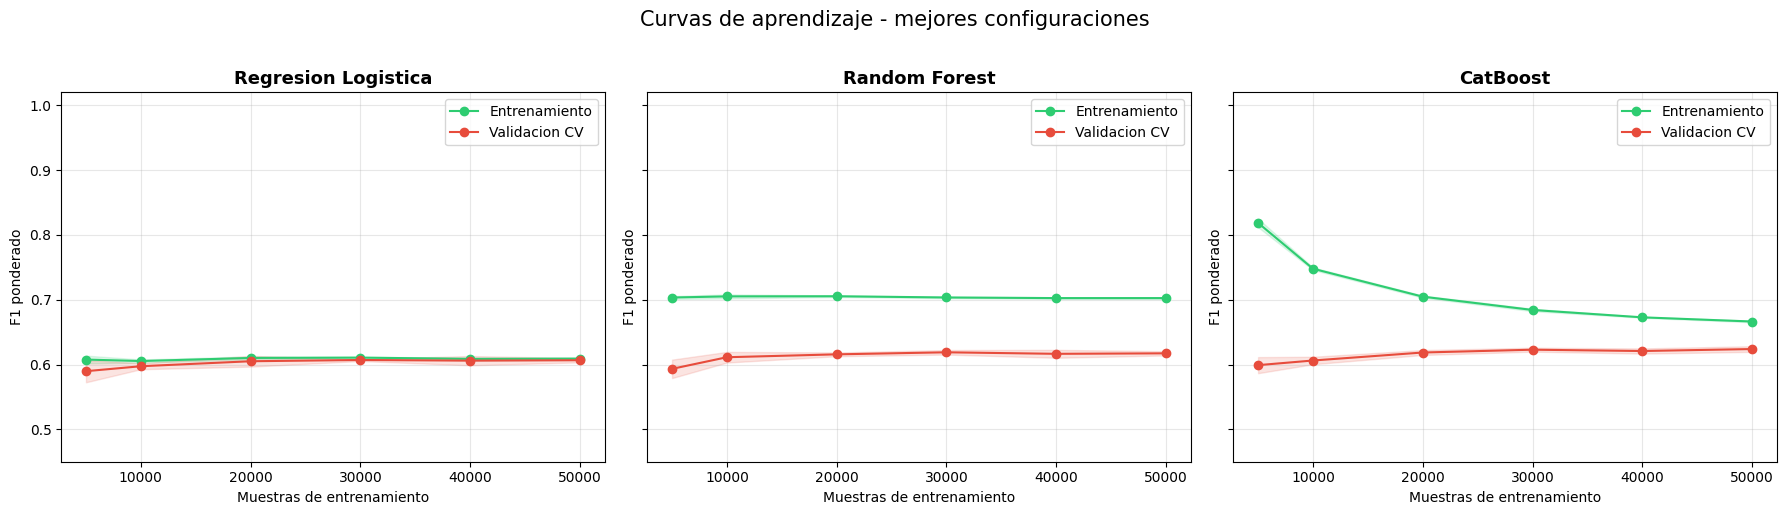

Figura guardada en imagenes_casobase/punto7_curvas_aprendizaje.png


In [66]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

best_models_for_lc = [
    ("Regresion Logistica",
     LogisticRegression(**{**configs_lr[mejor_lr_i], "max_iter": 3000}),
     X_cv_esc),
    ("Random Forest",
     RandomForestClassifier(**configs_rf[mejor_rf_i]),
     X_cv),
    ("CatBoost",
     CatBoostClassifier(**{k: v for k, v in configs_cb[mejor_cb_i].items()
                           if k not in ('od_type', 'od_wait', 'verbose')},
                        verbose=0),
     X_cv),
]

tamanios = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
N = len(X_cv)

def curva_aprendizaje_manual(modelo, X, y, tamanios, cv, scoring_fn):
    X = np.array(X) if not isinstance(X, np.ndarray) else X
    y = np.array(y)
    train_means, train_stds = [], []
    val_means,   val_stds   = [], []
    sizes_used = []
    for frac in tamanios:
        n = max(int(N * frac), 100)
        idx = np.random.RandomState(42).choice(N, n, replace=False)
        X_sub, y_sub = X[idx], y[idx]
        tr_scores, va_scores = [], []
        for tr_idx, va_idx in cv.split(X_sub, y_sub):
            import sklearn.base as _base
            m = _base.clone(modelo) if hasattr(_base, 'clone') else type(modelo)(**modelo.get_params())
            m.fit(X_sub[tr_idx], y_sub[tr_idx])
            tr_scores.append(scoring_fn(y_sub[tr_idx], m.predict(X_sub[tr_idx])))
            va_scores.append(scoring_fn(y_sub[va_idx], m.predict(X_sub[va_idx])))
        train_means.append(np.mean(tr_scores))
        train_stds.append(np.std(tr_scores))
        val_means.append(np.mean(va_scores))
        val_stds.append(np.std(va_scores))
        sizes_used.append(n)
    return np.array(sizes_used), np.array(train_means), np.array(train_stds), np.array(val_means), np.array(val_stds)

from sklearn.metrics import f1_score as _f1
scoring_fn = lambda yt, yp: _f1(yt, yp, average='weighted')

for ax, (nombre, modelo, X_lc) in zip(axes, best_models_for_lc):
    sizes, tr_m, tr_s, va_m, va_s = curva_aprendizaje_manual(
        modelo, X_lc, y_cv, tamanios, CV, scoring_fn)
    ax.plot(sizes, tr_m, 'o-', color='#2ecc71', label='Entrenamiento')
    ax.fill_between(sizes, tr_m - tr_s, tr_m + tr_s, alpha=0.15, color='#2ecc71')
    ax.plot(sizes, va_m, 'o-', color='#e74c3c', label='Validacion CV')
    ax.fill_between(sizes, va_m - va_s, va_m + va_s, alpha=0.15, color='#e74c3c')
    ax.set_title(nombre, fontsize=13, fontweight='bold')
    ax.set_xlabel('Muestras de entrenamiento')
    ax.set_ylabel('F1 ponderado')
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0.45, 1.02)

plt.suptitle('Curvas de aprendizaje - mejores configuraciones', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('imagenes_casobase/punto7_curvas_aprendizaje.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figura guardada en imagenes_casobase/punto7_curvas_aprendizaje.png")


## 7.5 Entrenamiento del modelo final (conjunto completo)

Con la configuración ganadora de cada algoritmo se re-entrena usando **todo** el conjunto de entrenamiento (308 415 filas). El conjunto de prueba permanece reservado para el Punto 8.

In [67]:
# Mejor Logistic Regression
cfg_lr_final = {**configs_lr[mejor_lr_i], "max_iter": 3000}
lr_final = LogisticRegression(**cfg_lr_final)
lr_final.fit(X_train_esc, y_train)

# Mejor Random Forest
cfg_rf_final = configs_rf[mejor_rf_i]
rf_final = RandomForestClassifier(**cfg_rf_final)
rf_final.fit(X_train, y_train)

# Mejor CatBoost (early stopping desactivado en entrenamiento final)
cfg_cb_final = {k: v for k, v in configs_cb[mejor_cb_i].items()
                if k not in ('od_type', 'od_wait')}
cb_final = CatBoostClassifier(**cfg_cb_final)
cb_final.fit(X_train, y_train)

# Resumen
resultados_finales = []
for nombre, modelo, X_ev in [
    ("Regresión Logística", lr_final, X_test_esc),
    ("Random Forest",       rf_final, X_test),
    ("CatBoost",            cb_final, X_test),
]:
    train_X = X_train_esc if nombre == "Regresión Logística" else X_train
    f1_tr = f1_score(y_train, modelo.predict(train_X), average='weighted')
    f1_te = f1_score(y_test,  modelo.predict(X_ev),    average='weighted')
    resultados_finales.append({
        "Algoritmo":       nombre,
        "Train F1":        round(f1_tr, 4),
        "Test F1":         round(f1_te, 4),
        "Gap (sobreajuste)": round(f1_tr - f1_te, 4),
    })

df_final = pd.DataFrame(resultados_finales)
print("Evaluación de modelos finales (entrenados con 308 k filas)")
display(df_final)
print("\nGap < 0.02 se considera aceptable (sin sobreajuste significativo).")


e:\UVG\Septimo\Mineria de Datos\proy1-md\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Evaluación de modelos finales (entrenados con 308 k filas)


,Algoritmo,Train F1,Test F1,Gap (sobreajuste)
0,Regresión Logística,0.6067,0.6051,0.0016
1,Random Forest,0.6942,0.6269,0.0673
2,CatBoost,0.6360,0.6311,0.0049



Gap < 0.02 se considera aceptable (sin sobreajuste significativo).


### Resumen para el informe (Punto 7)

Se evaluaron cuatro variantes de cada algoritmo mediante **validación cruzada estratificada (k=5)** sobre una submuestra de 50 000 registros, reportando el F1 ponderado en entrenamiento y validación para detectar sobreajuste.

**Regresión Logística** — regularización L1 y L2:
Todas las configuraciones convergieron a resultados prácticamente idénticos (Val F1 ≈ 0.607, gap ≈ 0.001). La variación de C entre 0.01 y 100 no produjo diferencias apreciables, lo que indica que el problema no requiere ajuste fino de regularización en un modelo lineal: la frontera de decisión lineal tiene una capacidad limitada independiente de la penalización aplicada. L1 y L2 obtuvieron el mismo desempeño. Modelo final: L2, C=1.0 (Test F1=0.605, gap=0.0016).

**Random Forest** — restricción de profundidad y tamaño de hojas:
Los árboles poco profundos (depth=5) mostraron subajuste claro (Val F1=0.548). Al aumentar la profundidad el F1 de validación creció, pero el gap train-val aumentó proporcionalmente. La configuración de mayor Val F1 (sin límite de profundidad, min_samples_leaf=10, max_features=0.5) obtuvo Val F1=0.618 pero con gap=0.085, el más alto de todos los algoritmos. El modelo final sobre el conjunto completo confirma sobreajuste significativo: Train F1=0.694, Test F1=0.627, gap=0.067. A pesar de la regularización implícita, Random Forest no generalizó tan bien como CatBoost en este dataset.

**CatBoost** — regularización L2 sobre hojas y early stopping:
El parámetro más influyente fue `l2_leaf_reg`: la configuración CB-4 (depth=6, l2=10) igualó el Val F1 de CB-3 (depth=8, l2=5) pero con un gap menor (0.020 vs 0.032), siendo el mejor balance entre desempeño y generalización. El early stopping redujo automáticamente las iteraciones (promedio 258–422 según fold), controlando el sobreajuste sin intervención manual. Modelo final: Test F1=0.631, gap=0.005, el menor de los tres algoritmos.

Los tres modelos finales fueron re-entrenados con el conjunto completo (308 415 filas) y se reservan para la evaluación definitiva del Punto 8. CatBoost ofrece el mejor balance entre F1 de prueba y ausencia de sobreajuste.